# Layer 6: a harder flow, entangled moons in eight dimensions

[Notebook 05](05_flow_matching.ipynb) ran the pipeline on a 2D toy that saturates by
$w\approx64$: past that, extra capacity buys nothing. This notebook makes the *same kind* of
problem genuinely harder, and watches the scaling regime stretch.

**The target.** Take $k=4$ independent moon-pairs, stack them into $\mathbb R^8$, and mix them
with a fixed random rotation $Q$:

$$x_1 = Q\,\big(m^{(1)},\,m^{(2)},\,m^{(3)},\,m^{(4)}\big),\qquad m^{(j)}\sim\text{two moons}.$$

The rotation entangles every coordinate with every plane: the velocity field cannot decompose
into independent 2D problems, so it must model the joint 8-dimensional geometry. Everything
else is unchanged: source $\mathcal N(0,I_8)$, linear path, conditional velocity target, MSE.
For inspection we rotate generated samples back with $Q^\top$ and look at the four planes.

dim=8, input=(x_t, t) in R^9, output=velocity in R^8
LR law: eta*(w,T) = 0.01382 (w/64)^-0.488 (T/2048)^-0.605


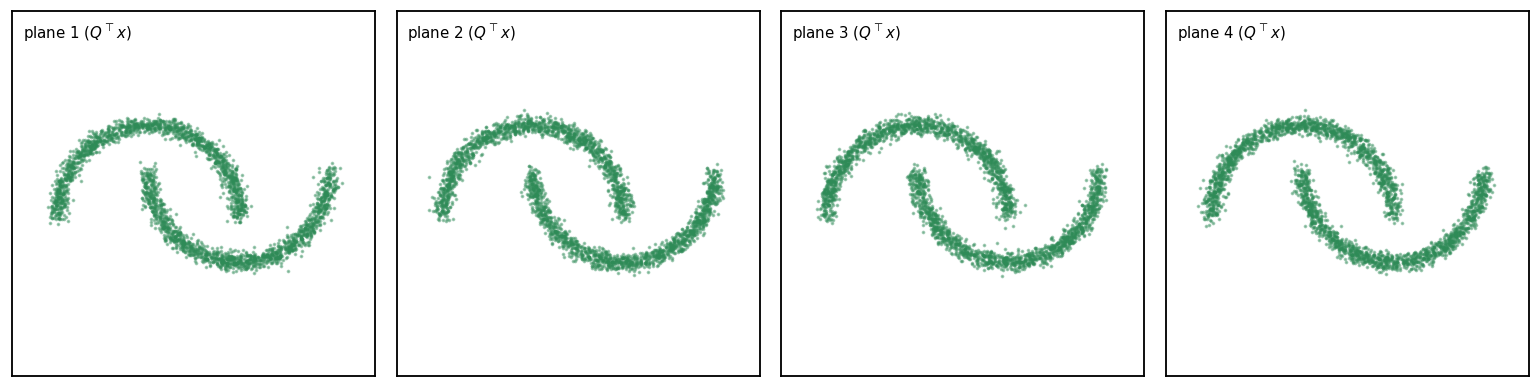

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from scaling_laws.flow import MultiMoonsFlow, two_moons
from scaling_laws.live import train_cell_live
from scaling_laws.sweep import aggregate, transfer_lr
from scaling_laws import approaches as ap, plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
prob = MultiMoonsFlow(n_pairs=4)
law = json.load(open(RESULTS / "flow8_hp_study_cosine.json"))
lr_of = transfer_lr(eta_ref=law["eta_ref"], w_ref=law["w_ref"], T_ref=law["T_ref"],
                    c_w=law["c_w"], c_T=law["c_T"], lr_max=0.1)
print(f"dim={prob.dim}, input=(x_t, t) in R^{prob.input_dim}, output=velocity in R^{prob.output_dim}")
print(f"LR law: eta*(w,T) = {law['eta_ref']} (w/{law['w_ref']})^{law['c_w']} (T/{law['T_ref']})^{law['c_T']}")

x1 = prob.unrotate(prob.sample_target(3000, torch.Generator().manual_seed(0)))
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for j, a in enumerate(axes):
    a.scatter(x1[:, 2*j], x1[:, 2*j+1], s=1.5, alpha=.4, color="seagreen")
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
    a.text(.03, .97, f"plane {j+1} ($Q^\\top x$)", transform=a.transAxes, va="top", fontsize=9)
fig.tight_layout(); plt.show()

## One field, eight dimensions

Same live loop; only the widths of the first and last layers changed. Note the loss scale:
the floor of this problem is different from the 2D one (conditioning in 8D is more
informative per coordinate), so the two problems are compared through their *excess*, not
their raw losses.

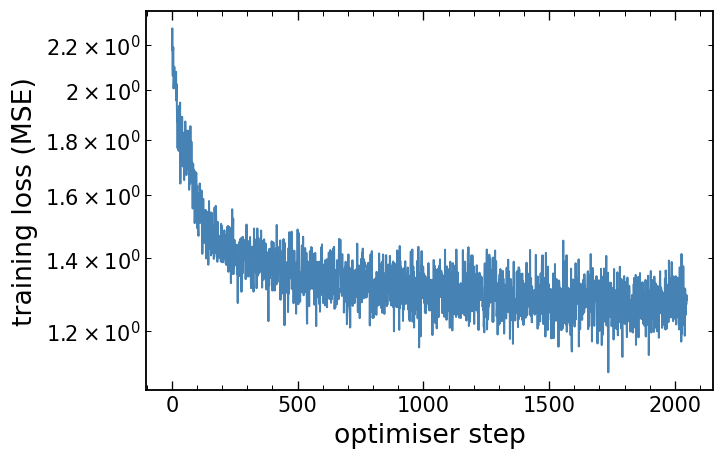

w=128, D=524,288:   0%|          | 0/2048 [00:00<?, ?step/s]

w=128, D=524,288:   2%|▏         | 51/2048 [00:00<00:06, 302.93step/s]

w=128, D=524,288:   5%|▍         | 102/2048 [00:00<00:05, 329.25step/s]

w=128, D=524,288:   7%|▋         | 153/2048 [00:00<00:05, 345.50step/s]

w=128, D=524,288:  10%|▉         | 204/2048 [00:00<00:05, 348.95step/s]

...

w=128, D=524,288:  95%|█████████▍| 1938/2048 [00:05<00:00, 337.41step/s]

w=128, D=524,288:  97%|█████████▋| 1989/2048 [00:05<00:00, 349.13step/s]

w=128, D=524,288: 100%|█████████▉| 2040/2048 [00:05<00:00, 347.72step/s]

w=128, D=524,288: 100%|█████████▉| 2047/2048 [00:05<00:00, 347.45step/s]

w=128, D=2^19: validation CFM loss = 1.2681


In [2]:
D = 2**19
val, steps, losses, model = train_cell_live(prob, 128, D, lr_of(128, prob.n_steps(D, 256)),
                                            return_model=True)
print(f"w=128, D=2^19: validation CFM loss = {val:.4f}")

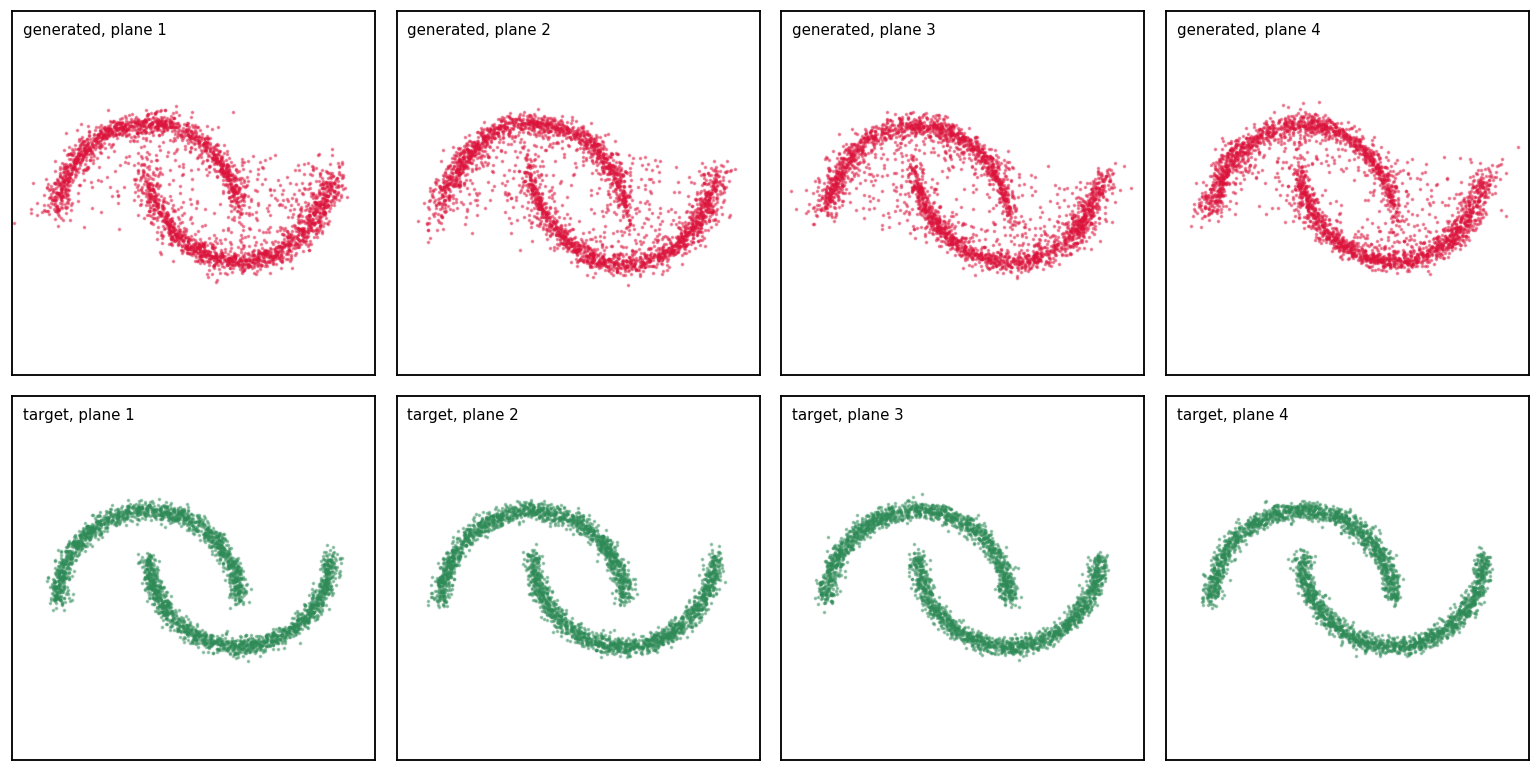

In [3]:
xg = prob.unrotate(prob.sample(model, n=3000, steps=100, seed=1))
xt = prob.unrotate(prob.sample_target(3000, torch.Generator().manual_seed(7)))
fig, axes = plt.subplots(2, 4, figsize=(13, 6.6))
for j in range(4):
    axes[0, j].scatter(xg[:, 2*j], xg[:, 2*j+1], s=1.5, alpha=.4, color="crimson")
    axes[1, j].scatter(xt[:, 2*j], xt[:, 2*j+1], s=1.5, alpha=.4, color="seagreen")
    axes[0, j].text(.03, .97, f"generated, plane {j+1}", transform=axes[0, j].transAxes,
                    va="top", fontsize=9)
    axes[1, j].text(.03, .97, f"target, plane {j+1}", transform=axes[1, j].transAxes,
                    va="top", fontsize=9)
for a in axes.ravel():
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
fig.tight_layout()
pl.save_figure(fig, "flow8_one_field", outdir=FIGDIR); plt.show()

## The generation ladder, again

The 2D ladder sharpened fully by $w{\approx}64$. Here small models visibly fail: they can
transport mass to roughly the right regions but cannot resolve four entangled moon-pairs at
once. Watch plane 1 across the ladder (all four planes behave alike).

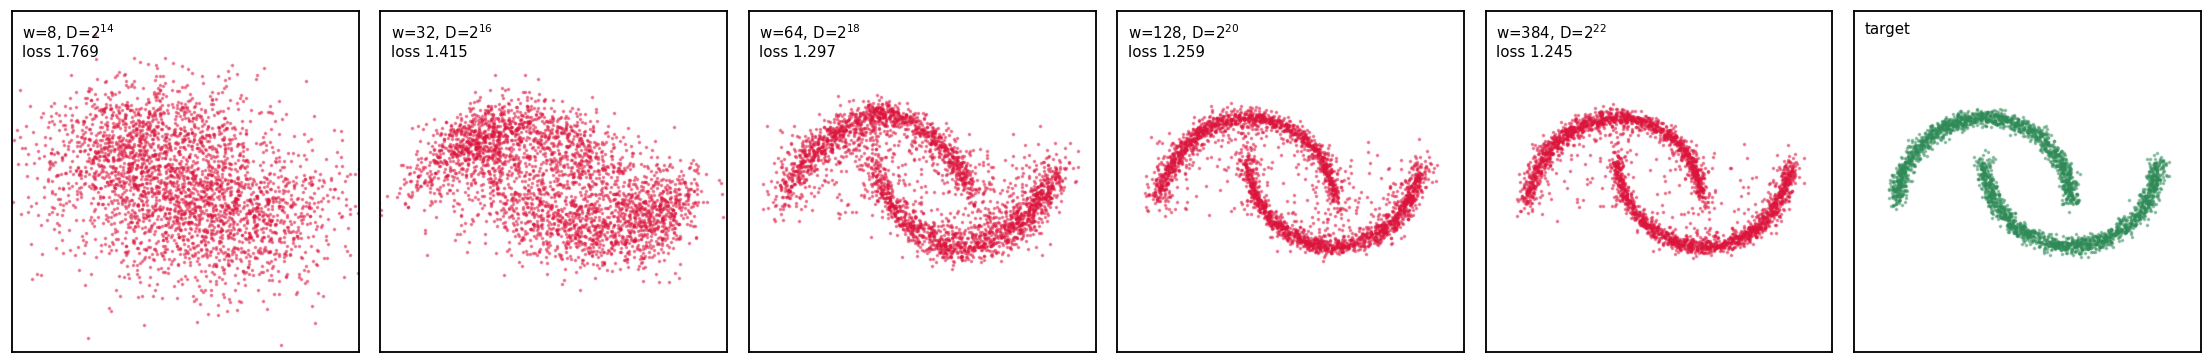

In [4]:
ladder = [(8, 2**14), (32, 2**16), (64, 2**18), (128, 2**20), (384, 2**22)]
fig, axes = plt.subplots(1, len(ladder) + 1, figsize=(3.1 * (len(ladder) + 1), 3.2))
for a, (w, D) in zip(axes, ladder):
    lv, _, _, m = train_cell_live(prob, w, D, lr_of(w, prob.n_steps(D, 256)),
                                  plot=False, progress=False, return_model=True)
    xs = prob.unrotate(prob.sample(m, 3000, seed=2))
    a.scatter(xs[:, 0], xs[:, 1], s=1.5, alpha=.4, color="crimson")
    a.text(.03, .97, f"w={w}, D=$2^{{{int(np.log2(D))}}}$\nloss {lv:.3f}",
           transform=a.transAxes, va="top", fontsize=9)
xs = prob.unrotate(prob.sample_target(3000, torch.Generator().manual_seed(3)))
axes[-1].scatter(xs[:, 0], xs[:, 1], s=1.5, alpha=.4, color="seagreen")
axes[-1].text(.03, .97, "target", transform=axes[-1].transAxes, va="top", fontsize=9)
for a in axes:
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
fig.tight_layout()
pl.save_figure(fig, "flow8_generation_ladder", outdir=FIGDIR); plt.show()

## The grid, three ways

[`run_flow_sweep.py --hard`](../scripts/run_flow_sweep.py) trained the $(N,D)$ grid (widths up
to 512, one more data octave than the 2D problem, per-cell LR from the re-calibrated law).

grid: 8 model sizes x 13 data budgets, N from 224 to 271,880 params


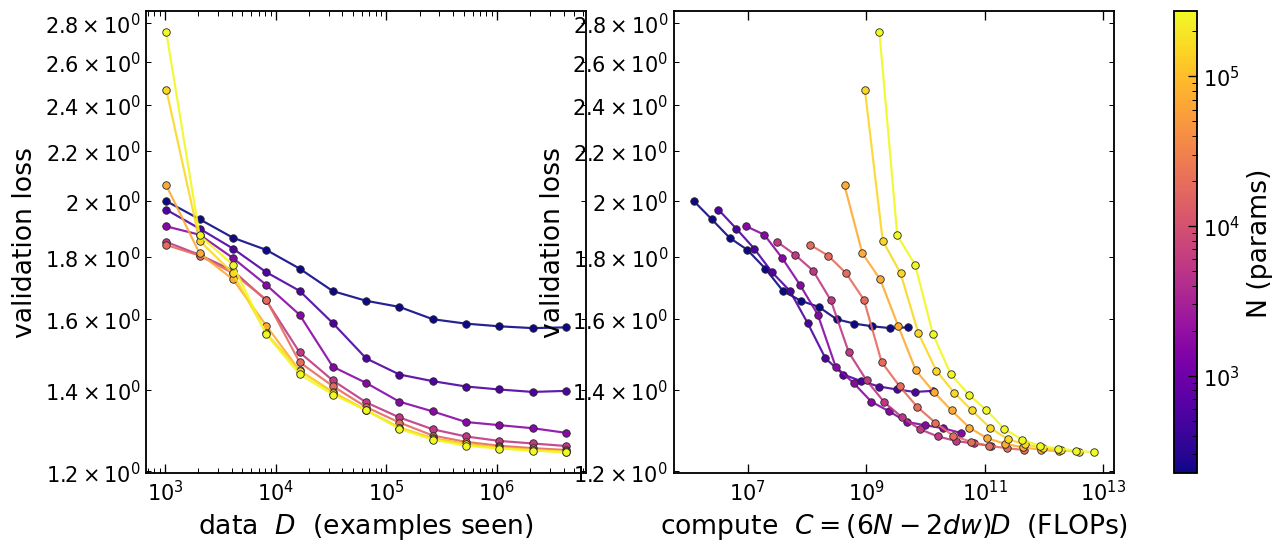

In [5]:
agg = aggregate(pd.read_csv(RESULTS / "flow8_sweep_cosine.csv"))
print(f"grid: {agg['N'].nunique()} model sizes x {agg['D'].nunique()} data budgets, "
      f"N from {agg['N'].min():,} to {agg['N'].max():,} params")
fig = pl.plot_all_runs(agg)
pl.save_figure(fig, "flow8_overview", outdir=FIGDIR); plt.show()

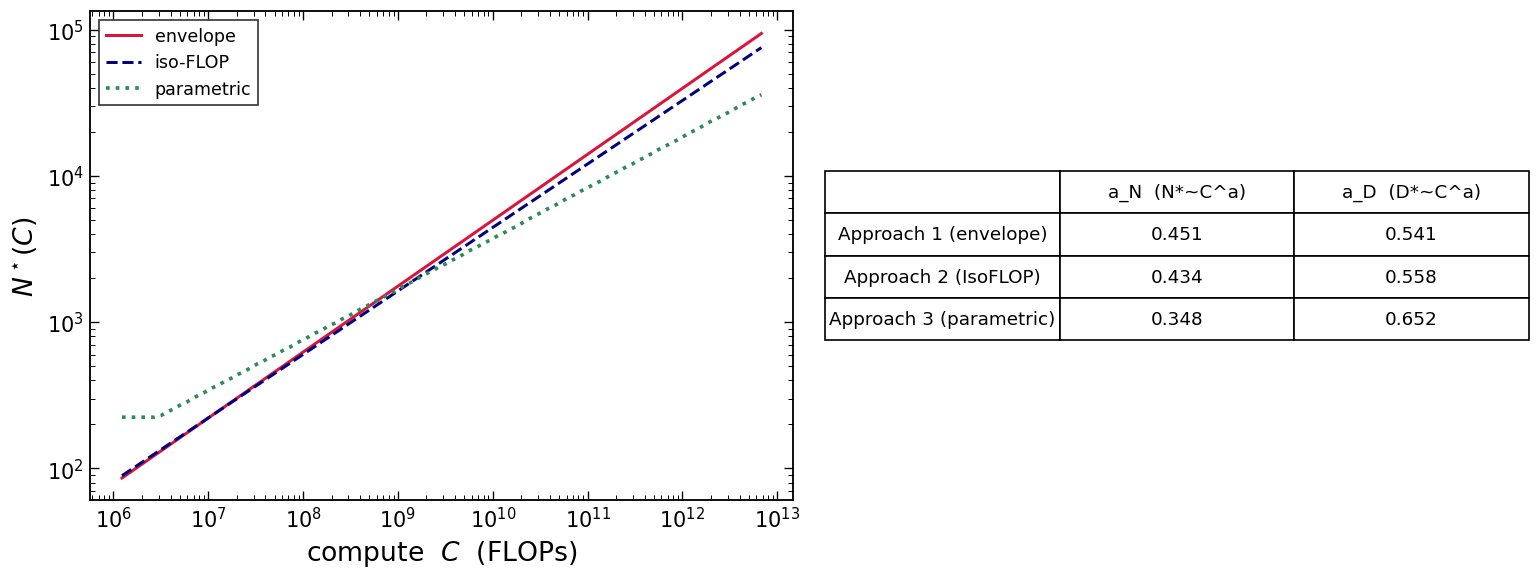

fitted floor (Approach 3):  E = 1.2136
exponents: alpha = 0.834, beta = 0.444, a_N = 0.348


In [6]:
env = ap.training_curve_envelope(agg)
iso = ap.isoflop_profiles(agg, n_targets=8)
par = ap.parametric_fit(agg)
fig = pl.plot_comparison(env, iso, par, (agg["C"].min(), agg["C"].max()))
pl.save_figure(fig, "flow8_comparison", outdir=FIGDIR); plt.show()
print(f"fitted floor (Approach 3):  E = {par.E:.4f}")
print(f"exponents: alpha = {par.alpha:.3f}, beta = {par.beta:.3f}, a_N = {par.a_N:.3f}")

## Floor and excess

In [7]:
D_ref = 2**22
val_ref, _, _, ref = train_cell_live(prob, 768, D_ref, lr_of(768, prob.n_steps(D_ref, 256)),
                                     plot=False, progress=True, return_model=True)
E_is, ess = prob.estimate_floor(n_points=2048, t_max=0.9)
mask = prob.x_val[:, -1] <= 0.9
sub = torch.nn.functional.mse_loss(ref(prob.x_val[mask]), prob.v_val[mask]).item()
print(f"reference model (w=768, D=2^22): loss = {val_ref:.4f}   <- empirical floor")
print(f"Approach 3 fitted floor:        E    = {par.E:.4f}")
print(f"IS floor, t<=0.9:               E    = {E_is:.4f}  (mean ESS {ess:.0f}; "
      f"weights concentrate faster in 8D, so trust it less than in 2D)")
print(f"reference model on t<=0.9:             {sub:.4f}  (apples-to-apples check)")

w=768, D=4,194,304:   0%|          | 0/16384 [00:00<?, ?step/s]

w=768, D=4,194,304:   0%|          | 23/16384 [00:00<01:12, 224.43step/s]

w=768, D=4,194,304:   0%|          | 51/16384 [00:00<01:04, 252.53step/s]

w=768, D=4,194,304:   0%|          | 78/16384 [00:00<01:03, 258.08step/s]

w=768, D=4,194,304:   1%|          | 105/16384 [00:00<01:02, 261.26step/s]

...

w=768, D=4,194,304: 100%|█████████▉| 16312/16384 [01:00<00:00, 288.87step/s]

w=768, D=4,194,304: 100%|█████████▉| 16341/16384 [01:00<00:00, 288.87step/s]

w=768, D=4,194,304: 100%|█████████▉| 16372/16384 [01:00<00:00, 294.11step/s]

w=768, D=4,194,304: 100%|█████████▉| 16383/16384 [01:00<00:00, 269.12step/s]

reference model (w=768, D=2^22): loss = 1.2441   <- empirical floor
Approach 3 fitted floor:        E    = 1.2136
IS floor, t<=0.9:               E    = 1.2655  (mean ESS 40258; weights concentrate faster in 8D, so trust it less than in 2D)
reference model on t<=0.9:             1.2768  (apples-to-apples check)


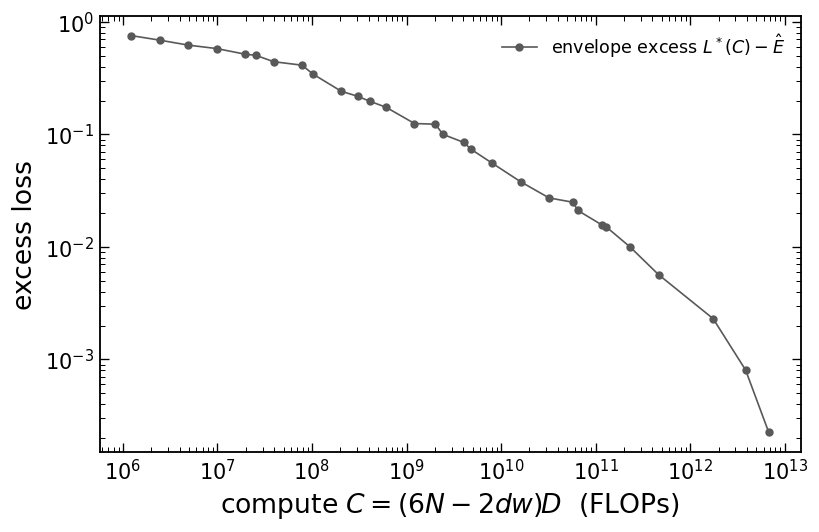

In [8]:
fr = env.frontier.sort_values("C")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(fr["C"], fr["val_loss"] - val_ref, "o-", color="0.35", ms=4, lw=1,
        label=r"envelope excess $L^*(C)-\hat E$")
ax.set(xscale="log", yscale="log", xlabel=r"compute $C=(6N-2dw)D$  (FLOPs)",
       ylabel="excess loss")
ax.legend(frameon=False)
fig.tight_layout()
pl.save_figure(fig, "flow8_excess", outdir=FIGDIR); plt.show()

## Takeaways

- **Difficulty stretches the scaling regime.** The 2D problem saturates by $w\approx64$; with
  four entangled planes the frontier keeps improving to the largest models in the grid. Harder
  targets push the capacity-limited term $A/N^\alpha$ out to larger $N$, which is what makes
  scaling laws worth measuring in the first place.
- **The same pipeline, untouched.** Only the problem class changed; the LR law was re-calibrated
  with the same script, and the three approaches ran verbatim.
- **Floors are problem-specific.** The 8D floor differs from the 2D one, and the IS estimator
  weakens in higher dimension (effective sample size drops), so the reference-model bound and
  the fitted $E$ carry more of the weight here.
- **Batch size is held fixed** at $b=256$ throughout; in principle it should be tuned and scaled
  jointly with $\eta$.